Matplotlib is building the font cache; this may take a moment.


--- Original DataFrame ---
   Age  Purchased
0   18          0
1   20          0
2   22          0
3   25          0
4   28          1
5   30          1
6   35          1
7   40          1
8   45          1
9   50          1

--- Final DataFrame ---
   Age  Purchased     Z  Probability  Prediction
0   18          0  -4.0     0.017986           0
1   20          0  -3.0     0.047426           0
2   22          0  -2.0     0.119203           0
3   25          0  -0.5     0.377541           0
4   28          1   1.0     0.731059           1
5   30          1   2.0     0.880797           1
6   35          1   4.5     0.989013           1
7   40          1   7.0     0.999089           1
8   45          1   9.5     0.999925           1
9   50          1  12.0     0.999994           1

--- Testing New Customers ---
Age: 21 | Probability: 0.0759 | Prediction: 0
-> Customer will not purchase

Age: 27 | Probability: 0.6225 | Prediction: 1
-> Customer will purchase

Age: 32 | Probability: 0.9526 

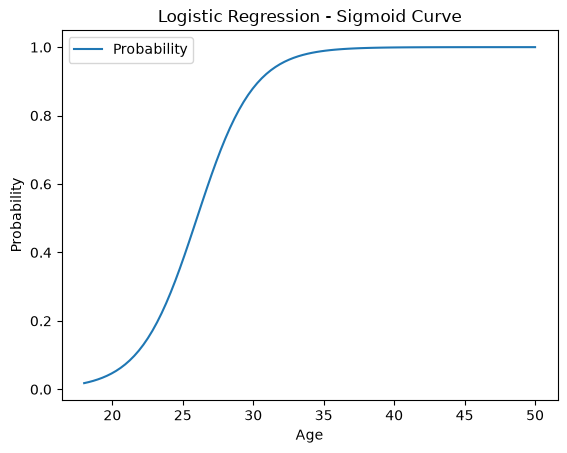

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt  
# Step 1: Dataset
data = {
    "Age": [18, 20, 22, 25, 28, 30, 35, 40, 45, 50],
    "Purchased": [0, 0, 0, 0, 1, 1, 1, 1, 1, 1]
}

df = pd.DataFrame(data)
print("--- Original DataFrame ---")
print(df)

# Step 2: Set parameters
w = 0.5
b = -13

X = df["Age"]
Y = df["Purchased"]

# Sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Step 3 & 4: Calculate linear score (Z) and sigmoid probability
Z = w * X + b
probability = sigmoid(Z)
# Step 5 & 6: Apply classification rule and add columns
prediction = np.where(probability >= 0.5, 1, 0)

df["Z"] = Z
df["Probability"] = probability
df["Prediction"] = prediction

# Step 7: Display final DataFrame
print("\n--- Final DataFrame ---")
print(df)

# Test New Customers
def predict_customer(age):
    z = w * age + b
    prob = sigmoid(z)
    pred = 1 if prob >= 0.5 else 0
    return prob, pred

test_ages = [21, 27, 32, 42]
print("\n--- Testing New Customers ---")
for age in test_ages:
    prob, pred = predict_customer(age)
    print(f"Age: {age} | Probability: {prob:.4f} | Prediction: {pred}")
    if pred == 1:
        print("-> Customer will purchase\n")
    else:
        print("-> Customer will not purchase\n")
        
x = np.linspace(18, 50, 100)
z = w * x + b
probability_curve = 1 / (1 + np.exp(-z))

df_curve = pd.DataFrame({"Age": x, "Probability": probability_curve})
print("--- Curve DataFrame Preview ---")
print(df_curve.head())

# Create and display the line plot
df_curve.plot(x="Age", y="Probability", kind="line", title="Logistic Regression - Sigmoid Curve")
plt.xlabel("Age")
plt.ylabel("Probability")
plt.show()  # Displays the plot cleanly in the output cell